# Example 17: Stateful Models and TBPTT

Standard backpropagation through time (BPTT) requires storing intermediate
activations for every timestep in a sequence. For very long sequences this
quickly exhausts GPU memory. Truncated Backpropagation Through Time (TBPTT)
solves this by splitting long sequences into manageable sub-windows while
carrying the RNN hidden state across them, enabling training on arbitrarily
long sequences with bounded memory.

## Prerequisites

This example builds on concepts from Examples 00-04. Make sure you have
completed those first.

## Setup

In [1]:
from tsfast.tsdata.benchmark import create_dls_silverbox
from tsfast.training import RNNLearner, fun_rmse

## The Memory Problem

When training RNNs, backpropagation stores intermediate activations for every
timestep. A sequence of length 10,000 requires roughly 100x more memory than
a sequence of length 100. For very long sequences this exceeds GPU memory.

TBPTT solves this by:

1. **Splitting** the long sequence into sub-windows (e.g., 100 timesteps each)
2. **Running** the forward pass on one sub-window at a time
3. **Computing gradients** only within each sub-window (truncated)
4. **Carrying the hidden state** from the end of one sub-window to the start
   of the next

This means the model still "sees" the full sequence through its hidden state,
but memory usage is bounded by `sub_seq_len` rather than the full sequence
length.

## Standard Training (Baseline)

First, train normally with a moderately large window to establish a reference
point. The full 500-step sequence is backpropagated through in one pass.

In [2]:
dls_standard = create_dls_silverbox(bs=16, win_sz=500, stp_sz=10)

lrn_standard = RNNLearner(dls_standard, rnn_type='lstm', hidden_size=40, metrics=[fun_rmse])
lrn_standard.fit_flat_cos(n_epoch=10, lr=3e-3)

Epoch 1/10:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 1/10:  93%|█████████▎| 280/300 [00:00<00:00, 559.68it/s]

Epoch 1/10: 100%|██████████| 300/300 [00:00<00:00, 559.68it/s, train=0.0158 | valid=0.0070 | fun_rmse=0.0116]

Epoch 1/10: 100%|██████████| 300/300 [00:00<00:00, 571.77it/s, train=0.0158 | valid=0.0070 | fun_rmse=0.0116]

Epoch 2/10:   0%|          | 0/300 [00:00<?, ?it/s]

...

Epoch 9/10: 100%|██████████| 300/300 [00:00<00:00, 919.62it/s, train=0.0034 | valid=0.0032 | fun_rmse=0.0097]

Epoch 9/10: 100%|██████████| 300/300 [00:00<00:00, 918.63it/s, train=0.0034 | valid=0.0032 | fun_rmse=0.0097]

Epoch 10/10:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 10/10: 100%|██████████| 300/300 [00:00<00:00, 946.09it/s, train=0.0028 | valid=0.0029 | fun_rmse=0.0096]

Epoch 10/10: 100%|██████████| 300/300 [00:00<00:00, 945.06it/s, train=0.0028 | valid=0.0029 | fun_rmse=0.0096]

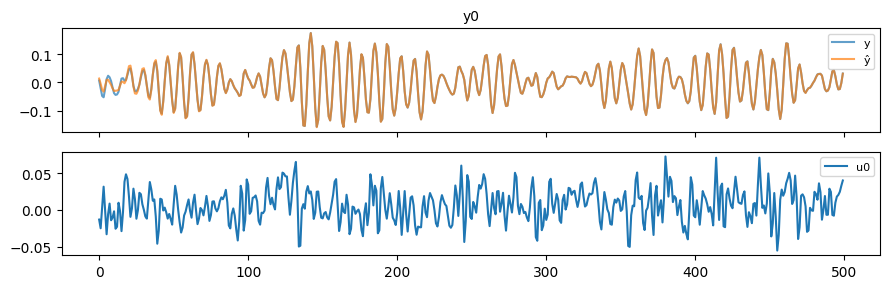

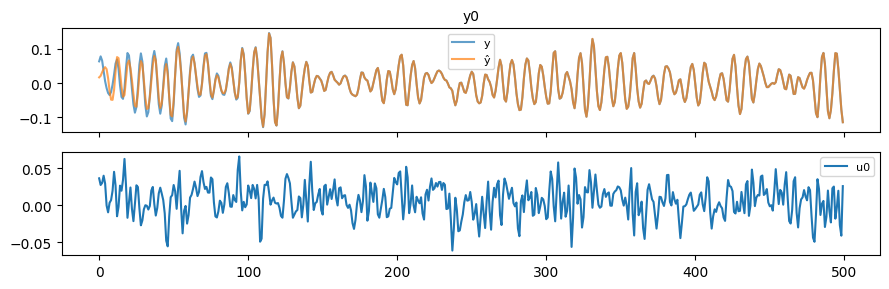

In [3]:
lrn_standard.show_results(max_n=2)

In [4]:
print(f"Standard: {lrn_standard.validate()}")

Standard: (0.002927627880126238, {'fun_rmse': 0.009641030803322792})


## TBPTT Training

The DataLoaders for TBPTT are identical to the baseline -- they yield full
500-step windows. The splitting into sub-windows happens inside the learner,
so `sub_seq_len` is a learner parameter, not a DataLoader parameter.

In [5]:
dls_tbptt = create_dls_silverbox(bs=16, win_sz=500, stp_sz=10)

## Stateful Model

Create a stateful RNN that maintains hidden state across sub-windows.

- **`sub_seq_len=100`** -- enables TBPTT: each 500-step window is split into
  5 sub-windows of 100 timesteps. The RNN does **not** reset its hidden
  state between sub-windows. Instead, the state from the previous sub-window
  initializes the next one, allowing information to flow across sub-window
  boundaries. The window size `win_sz` must be divisible by `sub_seq_len`.

When `sub_seq_len` is set, `RNNLearner` automatically uses `TbpttLearner`
and a stateful RNN. The hidden state is carried across the sub-windows of
one window and reset between batches, so the state from one training sample
never bleeds into the next, unrelated sample.

In [6]:
lrn_tbptt = RNNLearner(
    dls_tbptt, rnn_type='lstm', hidden_size=40,
    sub_seq_len=100, metrics=[fun_rmse],
)

## Train with TBPTT

Training proceeds exactly like standard training. Under the hood, the
learner splits each batch into sub-windows, runs forward/backward on each
sub-window in turn, and carries the detached hidden state from one
sub-window to the next.

In [7]:
lrn_tbptt.fit_flat_cos(n_epoch=10, lr=3e-3)

Epoch 1/10:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 1/10:  43%|████▎     | 129/300 [00:00<00:00, 258.00it/s]

Epoch 1/10:  86%|████████▌ | 258/300 [00:01<00:00, 250.06it/s]

Epoch 1/10: 100%|██████████| 300/300 [00:01<00:00, 250.06it/s, train=0.0078 | valid=0.0051 | fun_rmse=0.0103]

Epoch 1/10: 100%|██████████| 300/300 [00:01<00:00, 245.67it/s, train=0.0078 | valid=0.0051 | fun_rmse=0.0103]

...

Epoch 10/10:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 10/10:  44%|████▎     | 131/300 [00:00<00:00, 260.71it/s]

Epoch 10/10:  87%|████████▋ | 262/300 [00:01<00:00, 251.75it/s]

Epoch 10/10: 100%|██████████| 300/300 [00:01<00:00, 251.75it/s, train=0.0031 | valid=0.0029 | fun_rmse=0.0095]

Epoch 10/10: 100%|██████████| 300/300 [00:01<00:00, 255.77it/s, train=0.0031 | valid=0.0029 | fun_rmse=0.0095]

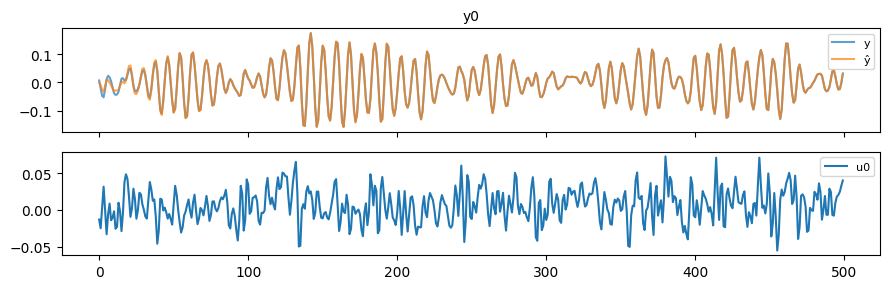

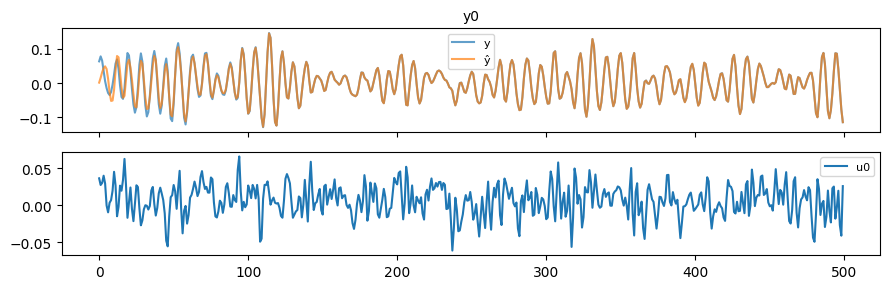

In [8]:
lrn_tbptt.show_results(max_n=2)

In [9]:
print(f"TBPTT: {lrn_tbptt.validate()}")

TBPTT: (0.0028908574022352695, {'fun_rmse': 0.009525912813842297})


## Comparison

Compare the final validation metrics for both approaches.

In [10]:
print(f"Standard (full BPTT):  {lrn_standard.validate()}")
print(f"Stateful (TBPTT):      {lrn_tbptt.validate()}")

Standard (full BPTT):  (0.002927627880126238, {'fun_rmse': 0.009641030803322792})
Stateful (TBPTT):      (0.0028908574022352695, {'fun_rmse': 0.009525912813842297})


TBPTT may have slightly different loss because gradients are truncated at
sub-window boundaries. However, performance should be comparable. The key
advantage is **memory efficiency** -- TBPTT can handle sequences that would
cause out-of-memory errors with standard training.

## When to Use TBPTT

TBPTT is most useful when:

- **Sequences are very long** (thousands of timesteps or more) and
  full backpropagation would exhaust GPU memory.
- **GPU memory is limited** and you need to keep memory usage bounded.
- **The system has long-range dependencies** that benefit from a large
  `win_sz`, but you cannot afford to backpropagate through the entire window.

For short sequences (under ~1000 timesteps), standard training is simpler and
usually sufficient. The overhead of managing sub-windows and stateful hidden
state is not worth the complexity for sequences that already fit in memory.

## Key Takeaways

- **TBPTT splits long windows into sub-windows** inside the learner; the
  DataLoaders are the same as for standard training.
- **`sub_seq_len`** in `RNNLearner` enables TBPTT and makes the RNN carry its
  hidden state across sub-windows instead of resetting to zero each time.
- **Hidden state is reset between batches** so different training samples do
  not bleed into each other.
- **Gradients are truncated** to `sub_seq_len` timesteps, bounding memory
  usage regardless of the full sequence length.
- **Hidden state spans the full sequence**, preserving long-range information
  even though gradients are truncated.
- **Use TBPTT when sequences are too long** for standard backpropagation to
  fit in GPU memory.